# Percolation Benchmark Analysis

This notebook is a thin interactive wrapper around `percolation_uart.analysis`.

It keeps the SQLite loading and plotting logic in the analysis module, so the notebook can stay lightweight while you inspect sessions, select a run, and render the standard plots inline.

In [1]:
from __future__ import annotations

import sys
import tempfile
from pathlib import Path

from IPython.display import Image, display

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'python' / 'percolation_uart' / 'analysis' / '__init__.py').exists():
            return candidate
    raise FileNotFoundError('could not locate repository root')

repo_root = find_repo_root()
python_dir = repo_root / 'python'
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from percolation_uart import analysis

db_path = analysis.DEFAULT_DB
plot_dir = repo_root / 'python' / 'output' / 'notebook_analysis'
plot_dir.mkdir(parents=True, exist_ok=True)
db_path, plot_dir

(PosixPath('/home/alessio/Documenti/FPGA-project/python/output/benchmark.sqlite3'),
 PosixPath('/home/alessio/Documenti/FPGA-project/python/output/notebook_analysis'))

In [2]:
conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    print(analysis.summarize_db(conn))
    print()
    for index, session in enumerate(sessions, start=1):
        payload = session.payload
        print(f'{index:2d}. session_id={session.session_id} created_at={session.created_at}')
        if 'config_hash' in payload:
            print(f'    config_hash={payload["config_hash"]}')
        if 'args' in payload and isinstance(payload['args'], dict):
            args = payload['args']
            print(f'    runs={args.get("runs")} repeats={args.get("repeats")} points={args.get("points")} steps={args.get("steps")}')
finally:
    conn.close()

sessions=202, summary_rows=4220, raw_rows=90400, p_range=[0.5300, 0.6800]

 1. session_id=acac4061-c9a4-4dce-a4b0-6d7f3c8d7e35 created_at=2026-05-28T07:50:16.274314+00:00
 2. session_id=b1569cd6-db3d-41f7-88ba-ff68a164fc22 created_at=2026-05-28T07:50:22.991661+00:00
 3. session_id=8b39bac8-3176-4297-b0c0-af600513f3ab created_at=2026-05-28T07:50:29.703517+00:00
 4. session_id=ac8871a4-4209-448a-98dc-3b76c2d031a0 created_at=2026-05-28T07:50:36.449012+00:00
 5. session_id=3dfcc997-83b2-453b-b7c4-71994d9fc012 created_at=2026-05-28T07:50:43.167524+00:00
 6. session_id=1c37b316-3fd6-48d4-b87a-52a83ad4c57e created_at=2026-05-28T07:50:56.341426+00:00
 7. session_id=b6a1acad-4292-407c-b66f-3b337a6a3a8a created_at=2026-05-28T07:51:09.457983+00:00
 8. session_id=4fafeee2-1de4-4df8-8daa-fe49859f7d53 created_at=2026-05-28T07:51:16.233173+00:00
 9. session_id=7a5c5dfe-2dc3-447d-9f50-9a90ff53de96 created_at=2026-05-28T07:51:22.934329+00:00
10. session_id=6c2e676a-4e22-436e-bcdf-88ccf98074d4 created_a

In [3]:
selected_session_index = 5-1

conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    if not sessions:
        raise RuntimeError(f'no sessions found in {db_path}')
    selected_session = sessions[selected_session_index]
    selected_session_id = selected_session.session_id
    summary_rows = analysis.load_summary_rows(conn, session_id=selected_session_id)
    raw_rows = analysis.load_raw_rows(conn, session_id=selected_session_id)
finally:
    conn.close()

print(f'selected_session_id={selected_session_id}')
print(f'selected_created_at={selected_session.created_at}')
print(f'summary_rows={len(summary_rows)} raw_rows={len(raw_rows)}')

selected_session_id=3dfcc997-83b2-453b-b7c4-71994d9fc012
selected_created_at=2026-05-28T07:50:43.167524+00:00
summary_rows=20 raw_rows=400


In [4]:
import matplotlib.pyplot as plt

runs = float(selected_session.payload.get('args', {}).get('runs', raw_rows[0]['runs']))
steps = float(selected_session.payload.get('args', {}).get('steps', raw_rows[0]['steps']))
ideal_core_cycles_per_run = steps * analysis.FRONTIER_CYCLES_PER_STEP + 3.0
baudrate = 115200.0
uart_wire_s = float(raw_rows[0].get('uart_wire_s', (analysis.REQUEST_BYTES + analysis.RESPONSE_BYTES) * 10.0 / baudrate))
wire_cycles_per_run = uart_wire_s * 100_000_000.0 / runs

dashboard.png


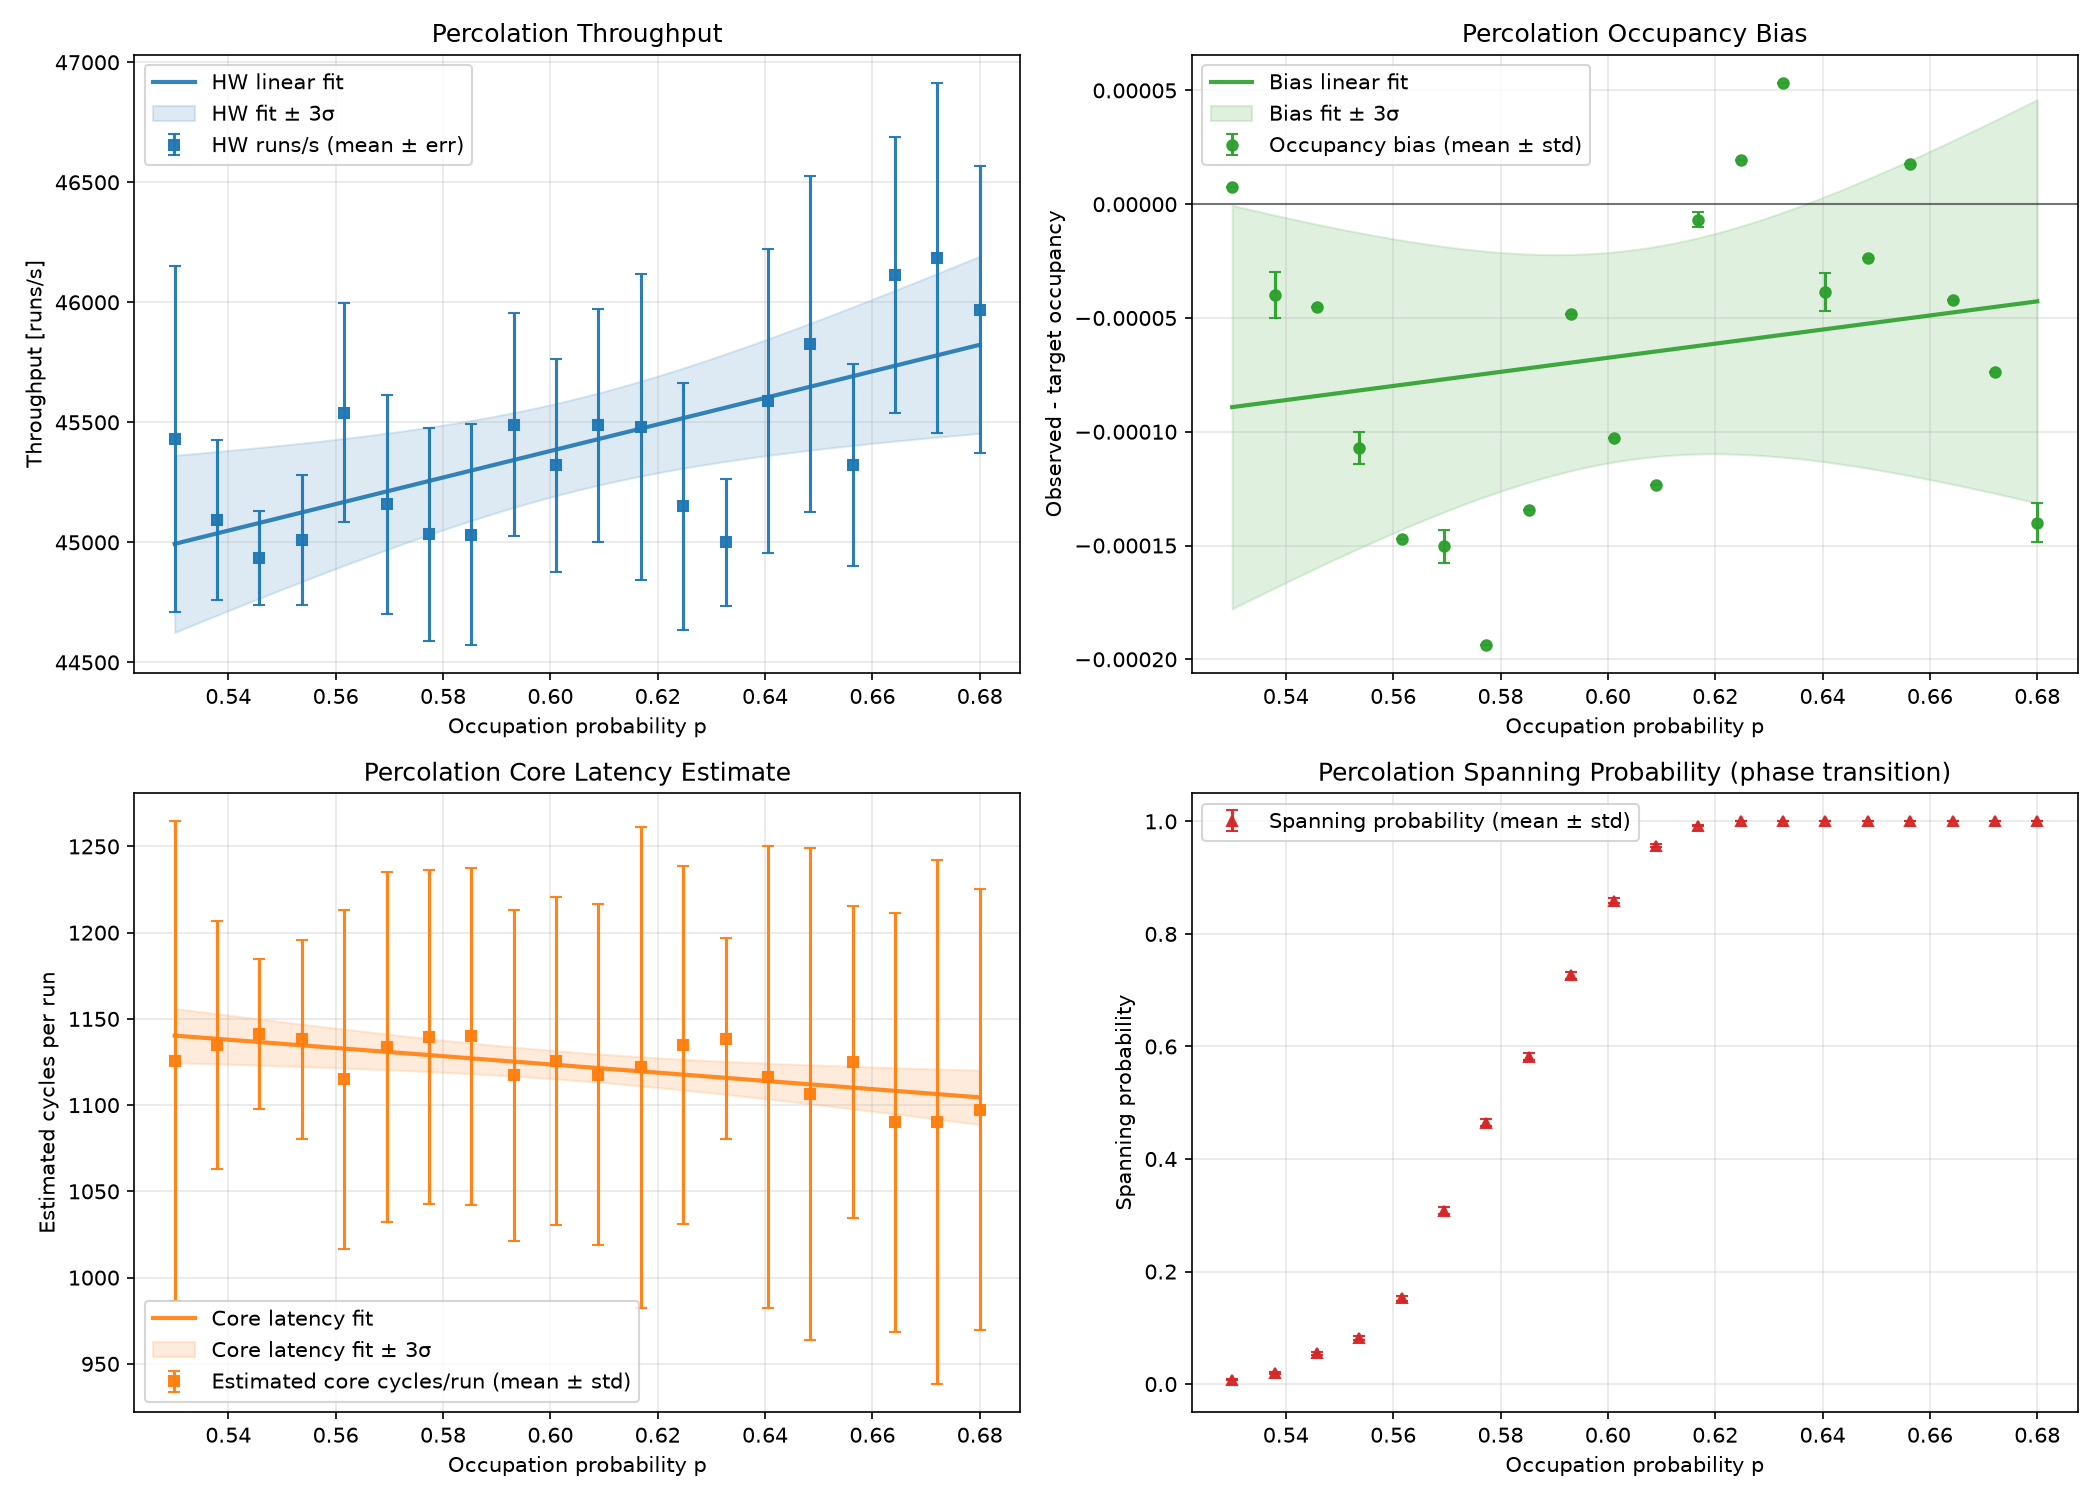

front_density.png


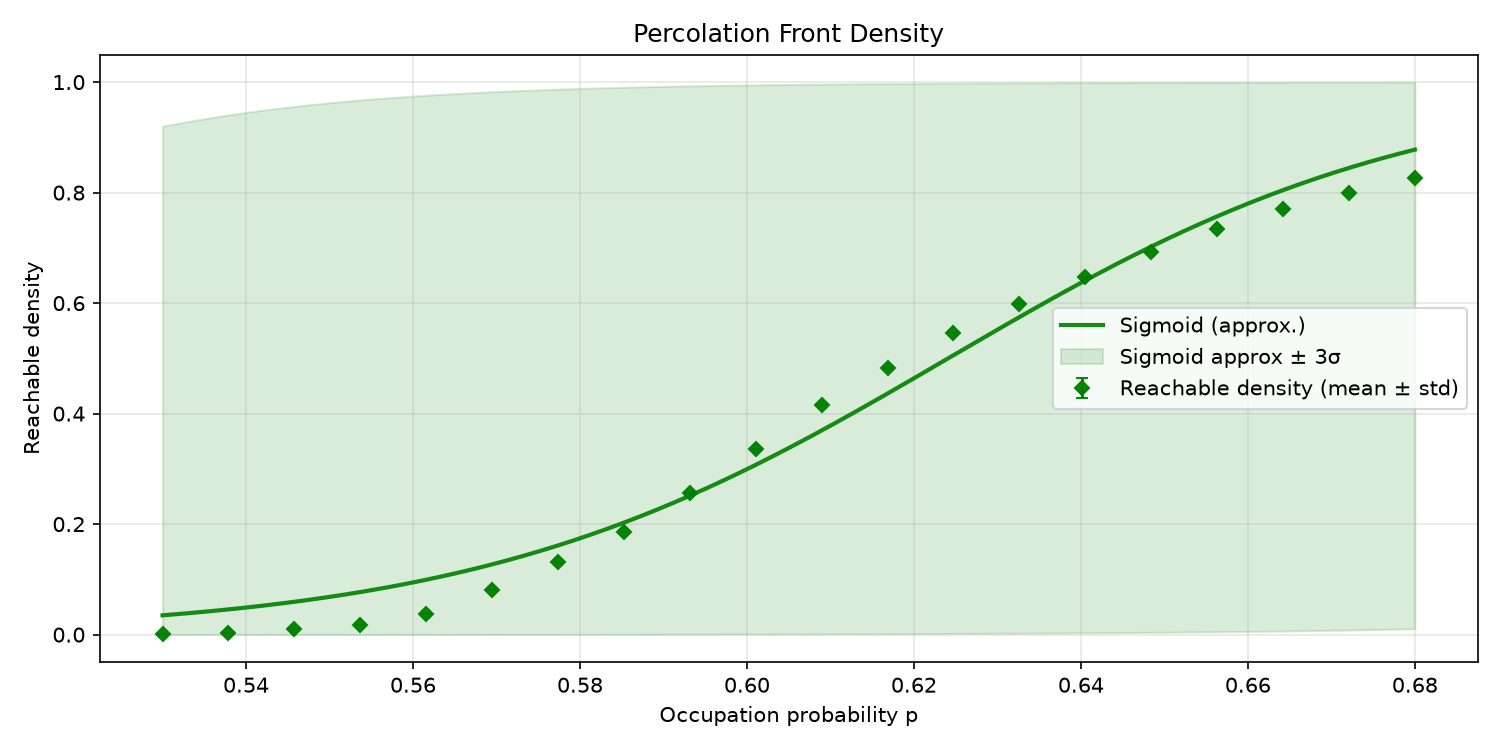

cluster_mass.png


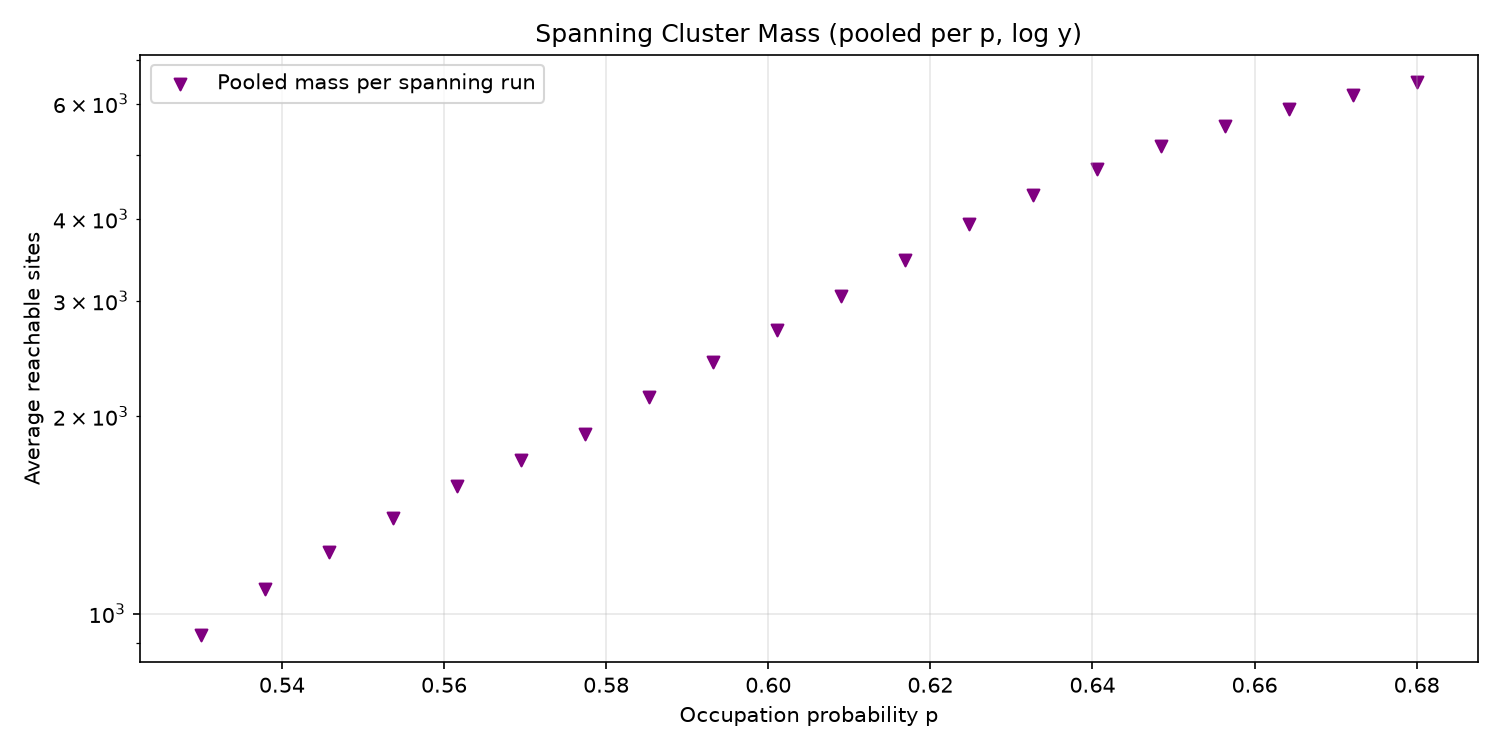

occupancy_bias.png


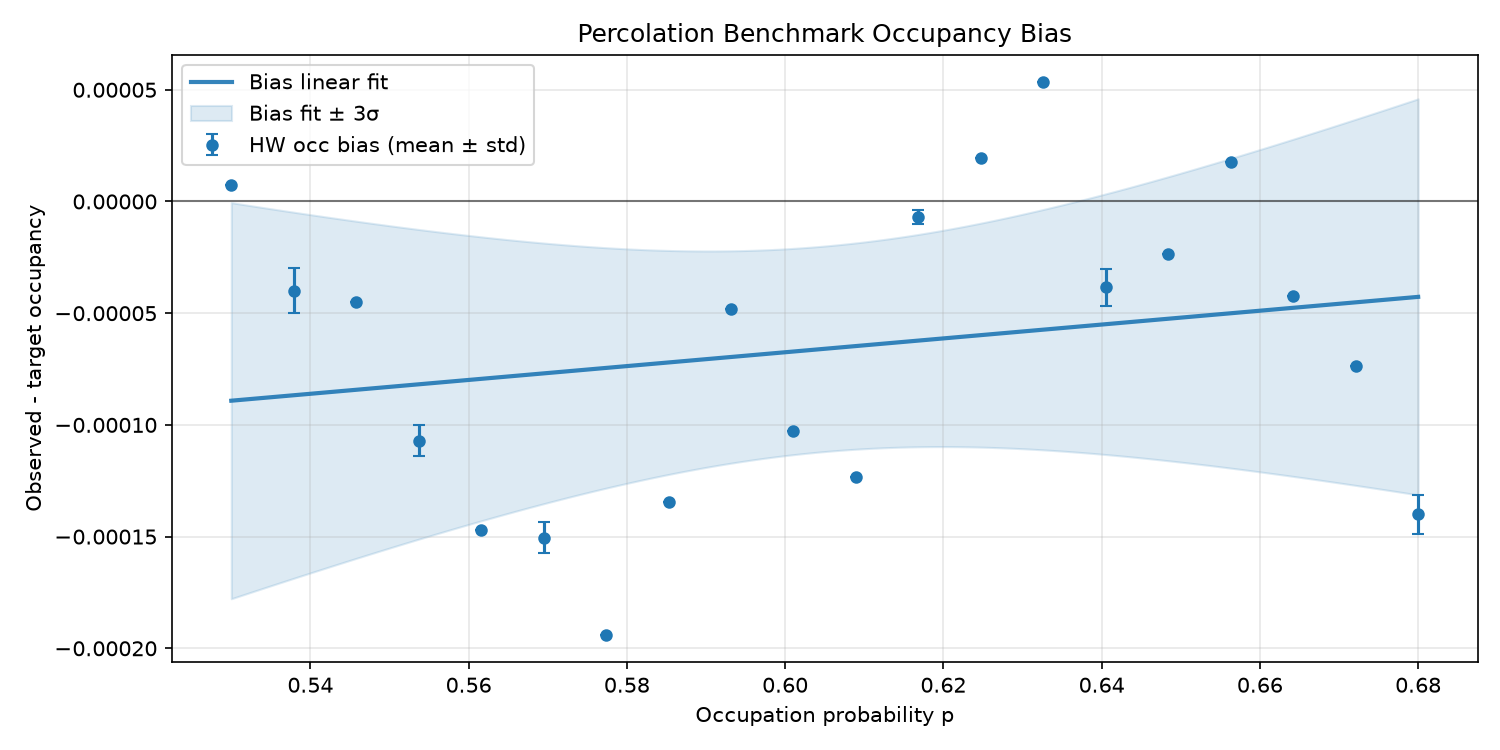

core_latency.png


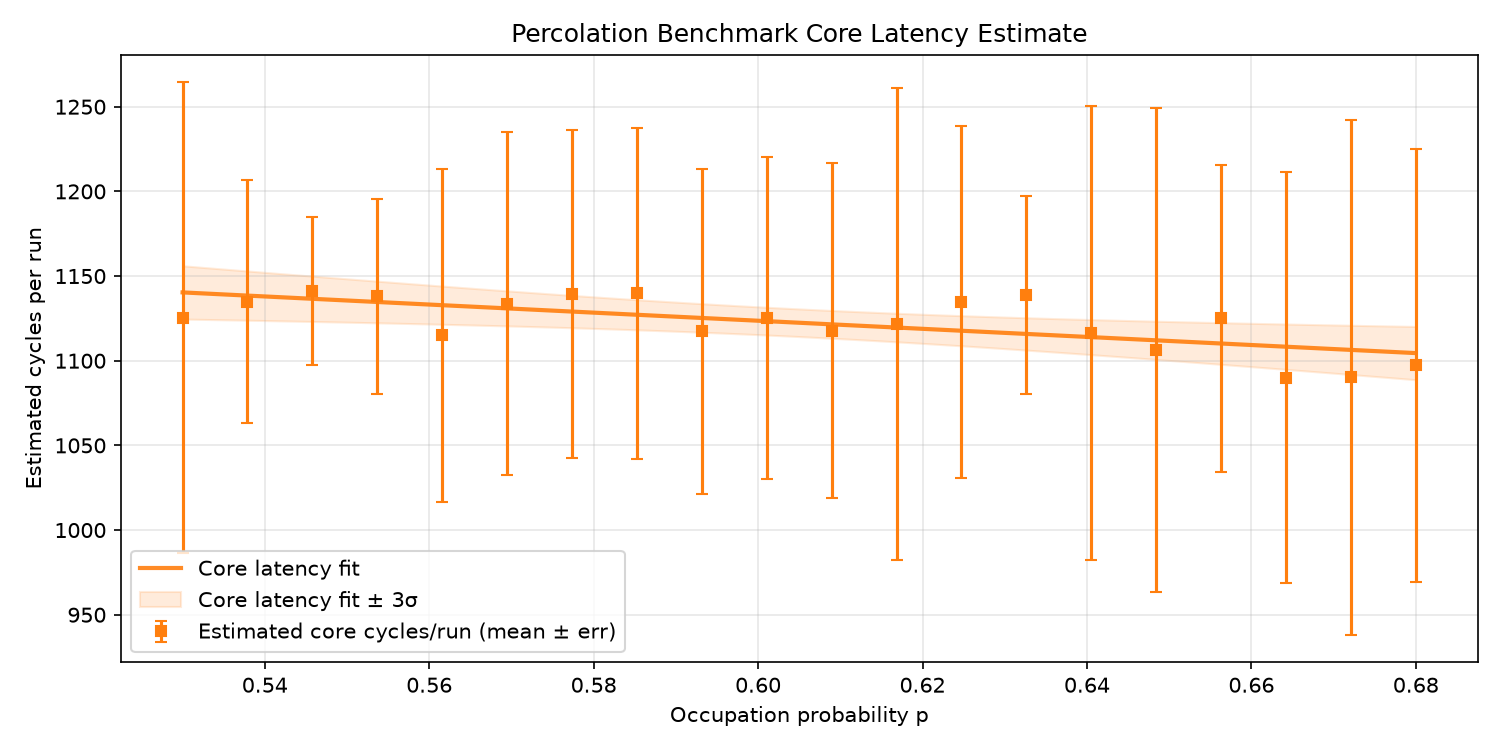

spanning_probability.png


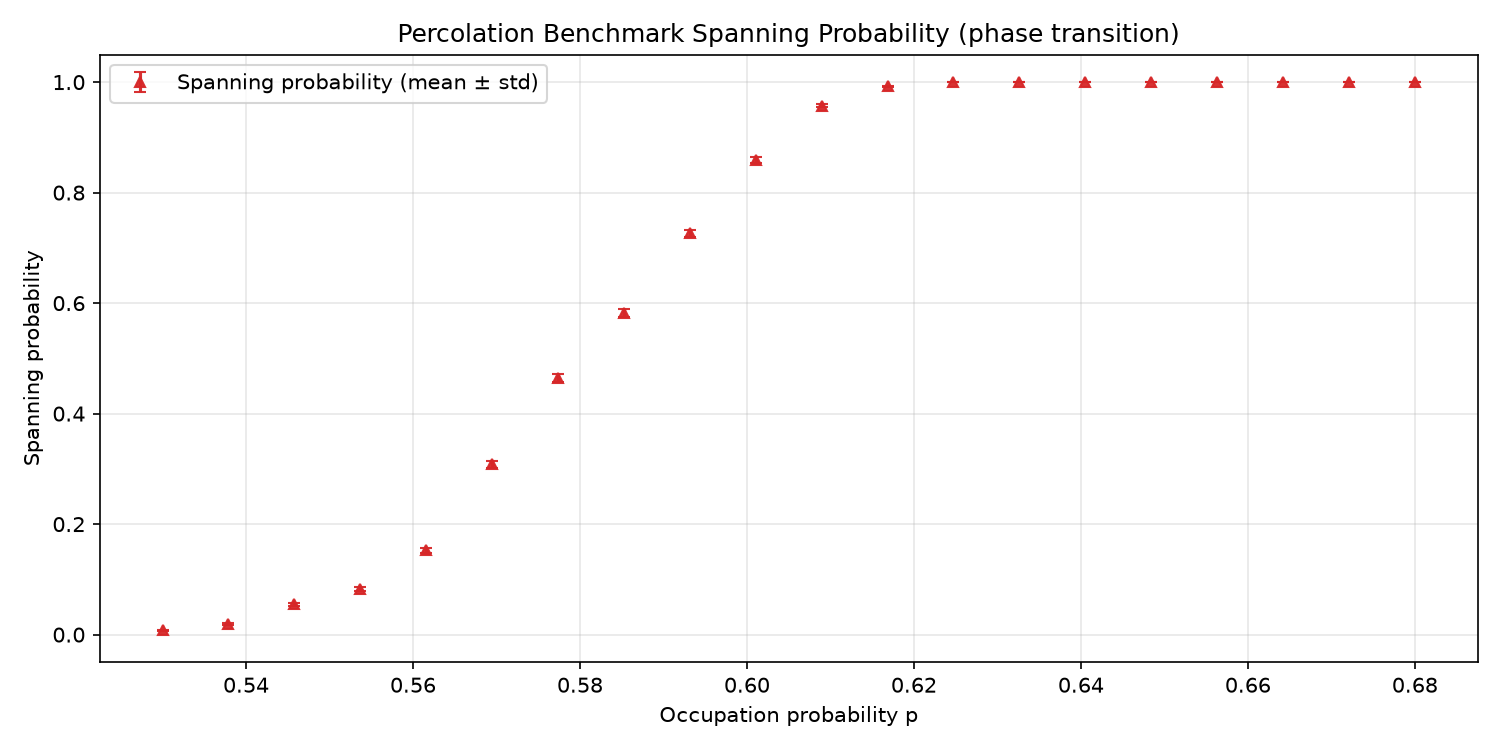

In [5]:
def render_png(path: Path) -> None:
    if not path.exists():
        print(f'missing: {path}')
        return
    display(Image(filename=str(path)))

session_plot_dir = plot_dir / selected_session_id
session_plot_dir.mkdir(parents=True, exist_ok=True)

analysis.plot_dashboard(summary_rows, raw_rows, session_plot_dir / 'dashboard.png')
analysis.plot_front_density(raw_rows, session_plot_dir / 'front_density.png')
analysis.plot_cluster_mass(raw_rows, session_plot_dir / 'cluster_mass.png')
analysis.plot_occupancy_bias(raw_rows, session_plot_dir / 'occupancy_bias.png')
analysis.plot_core_latency(raw_rows, session_plot_dir / 'core_latency.png')
analysis.plot_spanning_probability(raw_rows, session_plot_dir / 'spanning_probability.png')
plt.close('all')

for filename in [
    'dashboard.png',
    'front_density.png',
    'cluster_mass.png',
    'occupancy_bias.png',
    'core_latency.png',
    'spanning_probability.png',
]:
    print(filename)
    render_png(session_plot_dir / filename)

## Optional batch view

Change `selected_session_index` and rerun the selection and rendering cells to inspect another benchmark session.

If you want to compare several sessions at once, keep the analysis logic in the module and use a small loop here to render one subdirectory per session.

## Sweep Session Explorer

This section inspects the recent latency sweep sessions collected with fixed probability `p = 0.60` and compares them by `steps_per_run` and `cfg_runs`.

It stays inside the notebook so the analysis logic remains in `percolation_uart.analysis` while the notebook only orchestrates filtering and plotting.

In [6]:
SWEEP_RUNS = {1, 4, 16, 64, 256, 1024, 4096, 16384, 65600}
SWEEP_STEPS = {64, 128, 256, 512, 768, 1024, 2048}
SWEEP_WIDTHS = {64, 170, 128}

def _session_signature(summary_rows, raw_rows):
    if not raw_rows:
        return None
    first_row = raw_rows[0]
    return {
        'runs': int(first_row['runs']),
        'steps': int(first_row['steps']),
        'width': int(first_row.get('hw_width', first_row.get('width', 0))),
        'points': len(summary_rows),
        'raw_rows': len(raw_rows),
        'summary_rows': len(summary_rows),
        'p_values': sorted({float(row['p']) for row in summary_rows}),
    }

conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    sweep_sessions = []
    for session in sessions:
        summary_rows = analysis.load_summary_rows(conn, session_id=session.session_id)
        raw_rows = analysis.load_raw_rows(conn, session_id=session.session_id)
        signature = _session_signature(summary_rows, raw_rows)
        if signature is None:
            continue
        if signature['runs'] not in SWEEP_RUNS:
            continue
        if signature['steps'] not in SWEEP_STEPS:
            continue
        if SWEEP_WIDTHS is not None and signature['width'] not in SWEEP_WIDTHS:
            continue
        sweep_sessions.append((session, signature, summary_rows, raw_rows))
finally:
    conn.close()

print(f'found {len(sweep_sessions)} sweep sessions')
for index, (session, signature, summary_rows, raw_rows) in enumerate(sweep_sessions[-12:], start=max(1, len(sweep_sessions) - 11)):
    print(f'{index:2d}. session_id={session.session_id} created_at={session.created_at}')
    print(f'    runs={signature["runs"]} steps={signature["steps"]} width={signature["width"]} summary_rows={signature["summary_rows"]} raw_rows={signature["raw_rows"]}')
    print(f'    p_values={signature["p_values"]}')

found 96 sweep sessions
85. session_id=bca81ac6-eb9f-42c1-8da9-e6a70b50fc35 created_at=2026-05-28T15:08:00.905759+00:00
    runs=256 steps=768 width=64 summary_rows=20 raw_rows=400
    p_values=[0.53, 0.5378947368421053, 0.5457894736842106, 0.5536842105263158, 0.5615789473684211, 0.5694736842105264, 0.5773684210526316, 0.5852631578947369, 0.5931578947368421, 0.6010526315789474, 0.6089473684210527, 0.616842105263158, 0.6247368421052633, 0.6326315789473684, 0.6405263157894737, 0.648421052631579, 0.6563157894736843, 0.6642105263157895, 0.6721052631578948, 0.68]
86. session_id=bbf0569a-7c4a-4fb6-84c9-05267dfc27e5 created_at=2026-05-28T15:08:20.492344+00:00
    runs=1024 steps=768 width=64 summary_rows=20 raw_rows=400
    p_values=[0.53, 0.5378947368421053, 0.5457894736842106, 0.5536842105263158, 0.5615789473684211, 0.5694736842105264, 0.5773684210526316, 0.5852631578947369, 0.5931578947368421, 0.6010526315789474, 0.6089473684210527, 0.616842105263158, 0.6247368421052633, 0.6326315789473684

In [7]:
    ideal_core_cycles = steps * analysis.FRONTIER_CYCLES_PER_STEP + 3.0

## FPGA Engineering Analysis

This section uses `benchmark-2.sqlite3` (the systematic runs/step sweeps) to
produce FPGA-performance plots. Each plot is generated via `analysis.py` and
displayed inline.

The plots cover:
- **Latency vs Batch**: Amdahl-style speedup, showing how UART overhead gets amortized
- **Breakdown + Throughput**: Side-by-side asymptotic decomposition — core cycles/run
  (fixed + marginal cost) and throughput in rows/s (Amdahl saturation)
- **Asymptotic Breakdown**: Separates fixed (host+UART) from marginal (FPGA core) cost
- **Pipeline Efficiency**: How close the frontier pipeline is to the ideal 3 cyc/step
- **Throughput Invariance**: Throughput stability across grid heights, with asymptotic
  rows/s fits (cells/s left, asymptotic throughput right)
- **Throughput Contour**: 2D heatmap of performance
- **Determinism CV**: Coefficient of variation across repeats

Run all cells below to generate and view the plots.


### FPGA Engineering: Latency vs Batch Size & Amdahl Speedup

Left panel: total latency vs batch size (log-log). Flat at small R (UART-dominated),
linear once core time dominates. Right panel: speedup relative to R=1. The
annotated `f_serial` is the Amdahl serial fraction — the irreducible UART overhead.

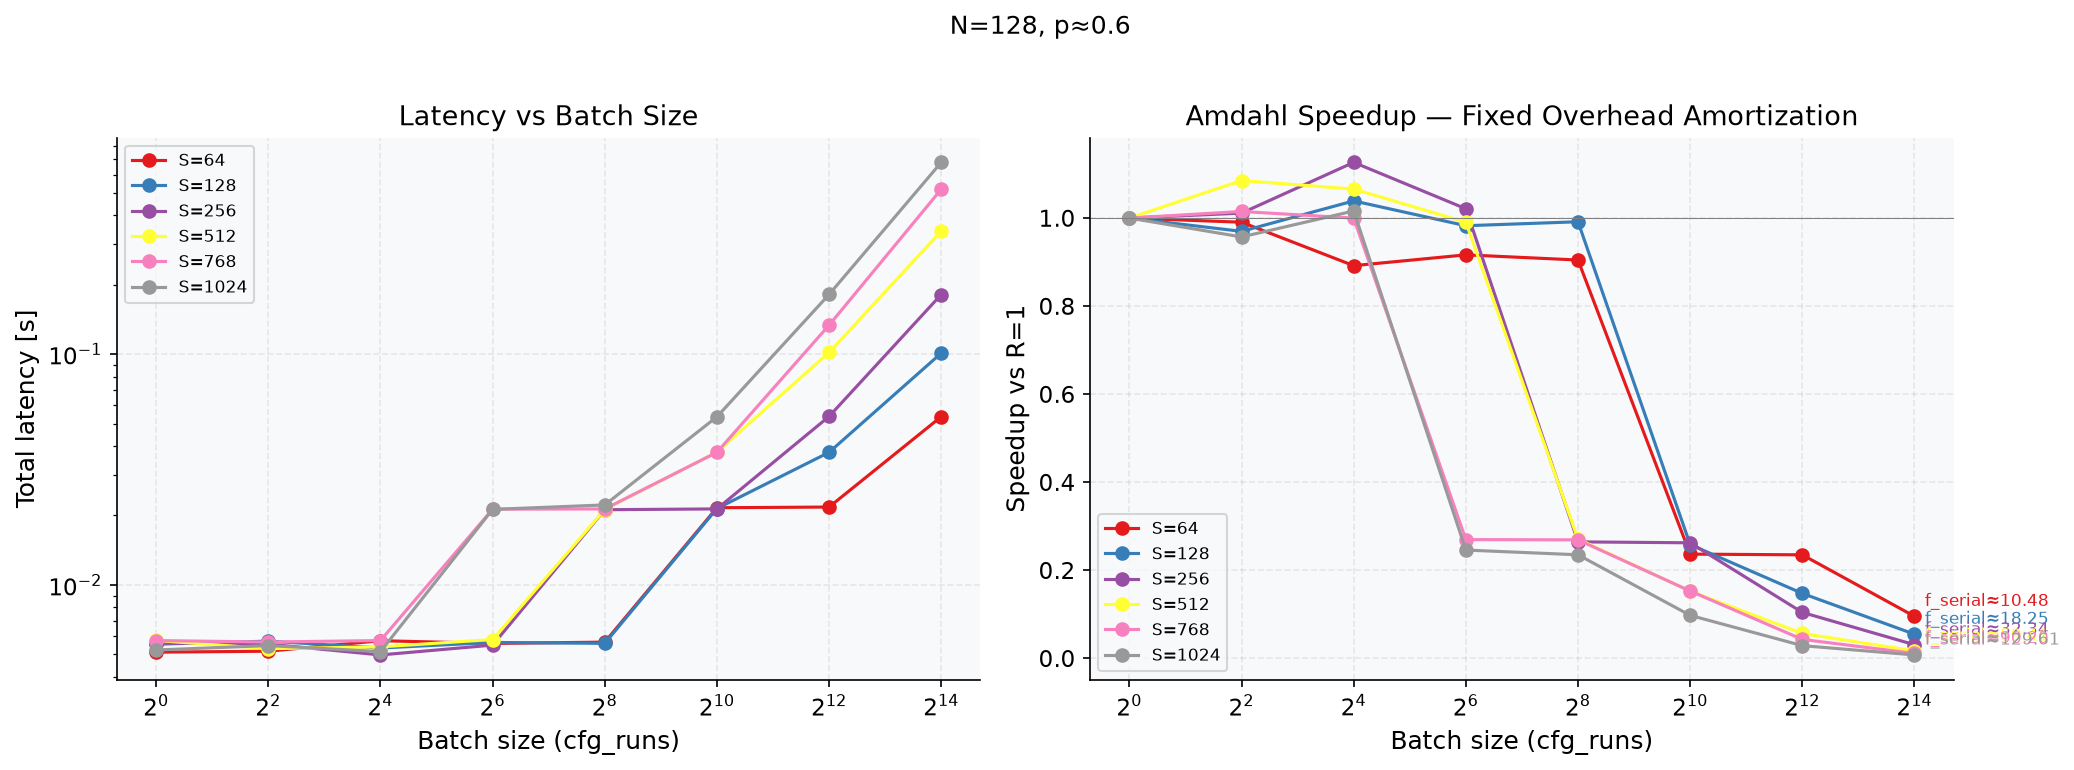

In [8]:
from percolation_uart import analysis
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display

from percolation_uart.analysis import plot_pipeline_efficiency

db2_path = repo_root / 'python' / 'output' / 'benchmark.sqlite3'
conn2 = analysis._connect(db2_path)
fpga_out = plot_dir / 'fpga_engineering'
fpga_out.mkdir(parents=True, exist_ok=True)

# 1. Latency vs Batch
analysis.plot_latency_vs_batch(conn2, fpga_out / 'latency_vs_batch.png')
display(Image(filename=str(fpga_out / 'latency_vs_batch.png')))

### FPGA Engineering: Breakdown vs Throughput (side by side)

Left panel: asymptotic cycles-per-run decomposition (core cycles/run → marginal cost).
Right panel: the same fit expressed as Amdahl throughput saturation in rows/s, with the
asymptote `steps×f_clk / C_marginal` as the batch size R→∞.



=== Breakdown vs Throughput (N=128, p≈0.6) ===
 steps  C_marginal     C_fixed    ideal(S×3)   overhead    util   asympt rows/s
----------------------------------------------------------------------------
    64       287.7      767065         256.0       31.7   89.0%        22242557
   128       582.4      757545         512.0       70.4   87.9%        21977360
   256      1059.1      847361        1024.0       35.1   96.7%        24171779
   512      2040.0      983435        2048.0       -8.0  100.4%        25098222
   768      3103.4      887340        3072.0       31.4   99.0%        24746914
  1024      4081.5     1002357        4096.0      -14.5  100.4%        25088894


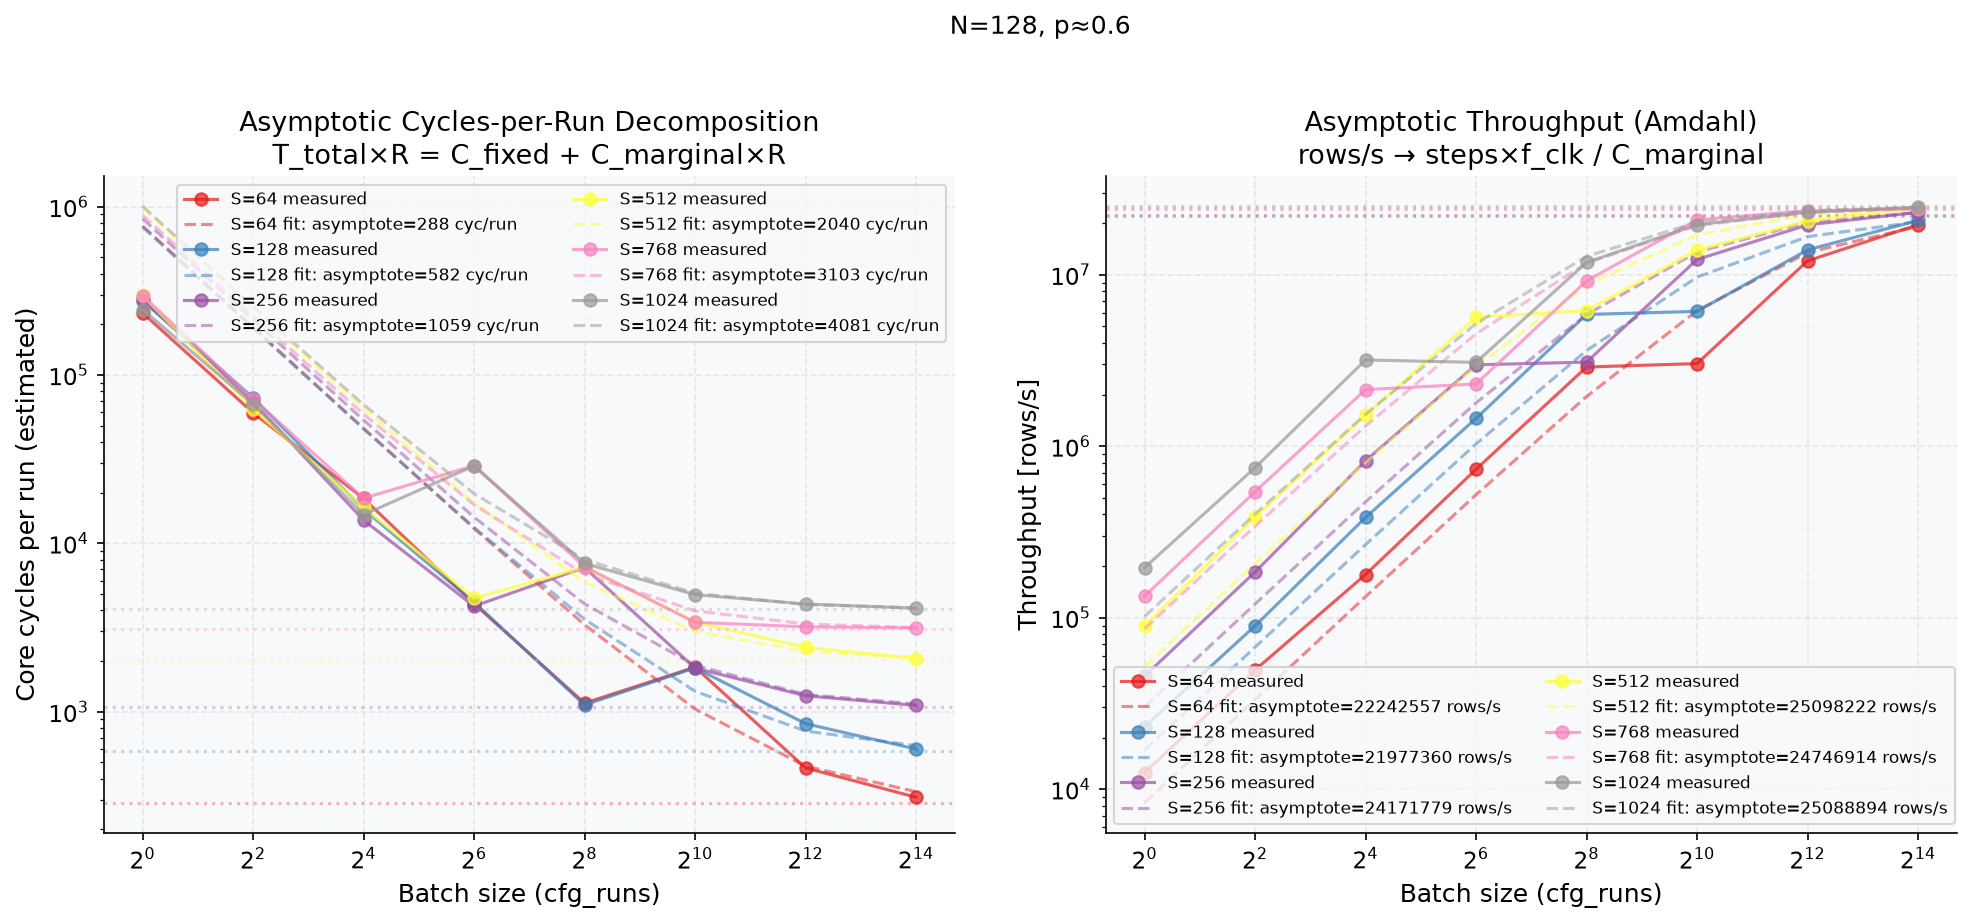


=== Asymptotic Fit Results (N=128, p≈0.6) ===
 steps  C_marginal     C_fixed    ideal(S×3)   overhead    util
-----------------------------------------------------
    64       287.7      767065         256.0       31.7   89.0%
   128       582.4      757545         512.0       70.4   87.9%
   256      1059.1      847361        1024.0       35.1   96.7%
   512      2040.0      983435        2048.0       -8.0  100.4%
   768      3103.4      887340        3072.0       31.4   99.0%
  1024      4081.5     1002357        4096.0      -14.5  100.4%


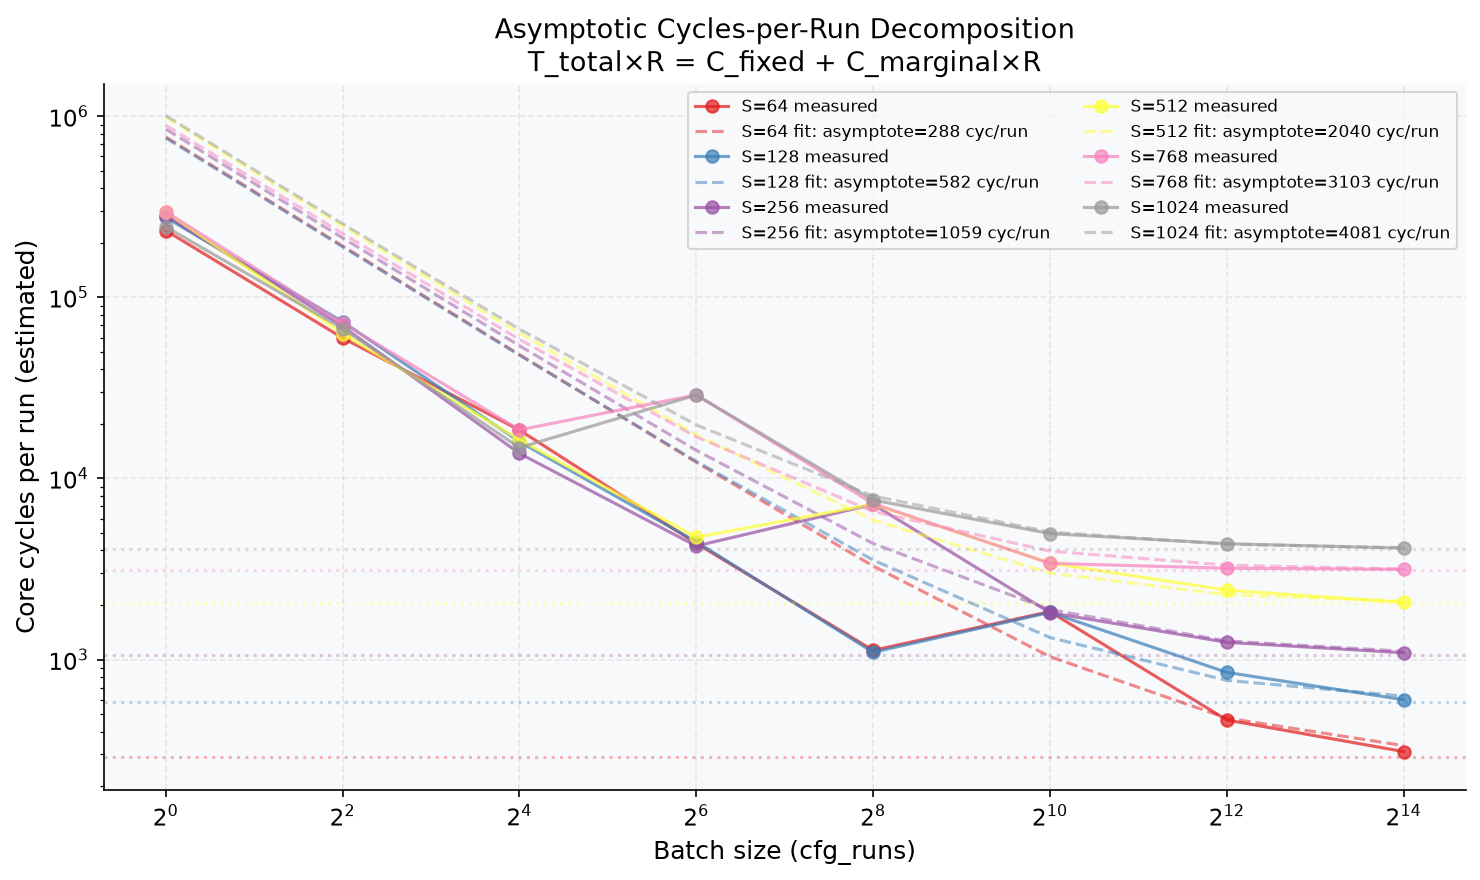


=== Pipeline Efficiency (N=128, R=16384, p≈0.6) ===
  Fit: C_core/run = 3.962 × steps + 71.0
  Ideal frontier: 4 cyc/step + 3
  Per-step cost:  3.962 cyc/step (vs ideal 4, excess -0.038/step)
  Residual host overhead (fitted intercept − ideal): 68.0 cyc/run

    S=  64: measured=310  ideal=259  excess=51  efficiency=83.5%
    S= 128: measured=600  ideal=515  excess=85  efficiency=85.9%
    S= 256: measured=1089  ideal=1027  excess=62  efficiency=94.3%
    S= 512: measured=2067  ideal=2051  excess=16  efficiency=99.2%
    S= 768: measured=3145  ideal=3075  excess=70  efficiency=97.8%
    S=1024: measured=4118  ideal=4099  excess=19  efficiency=99.5%


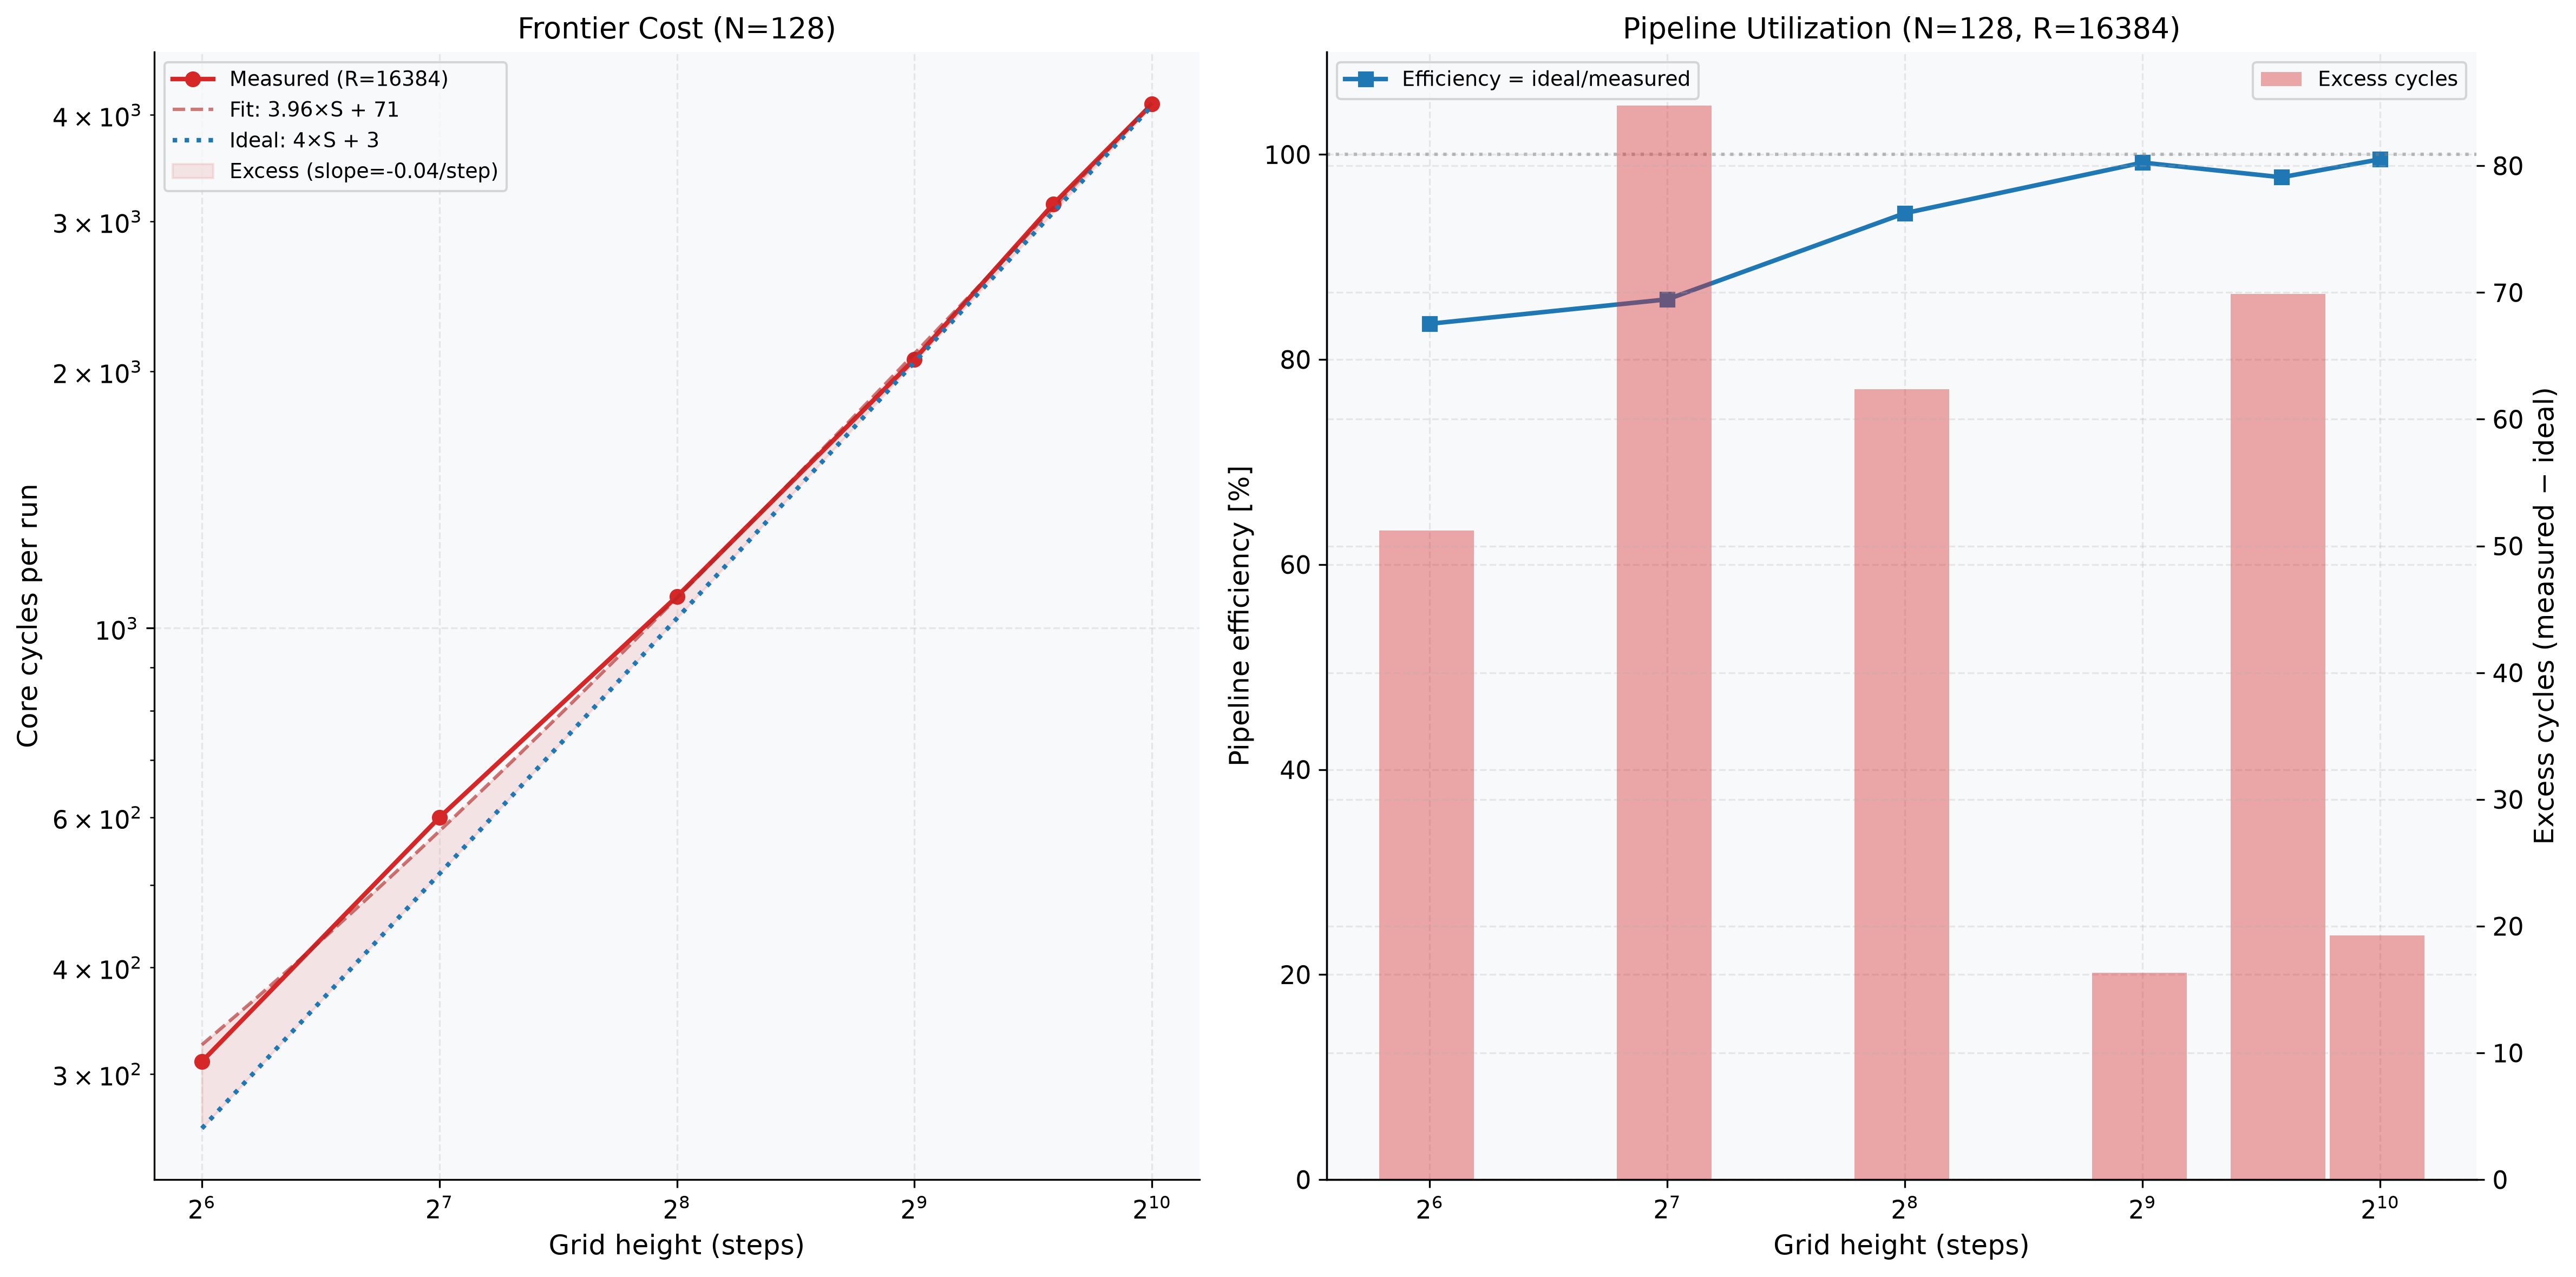

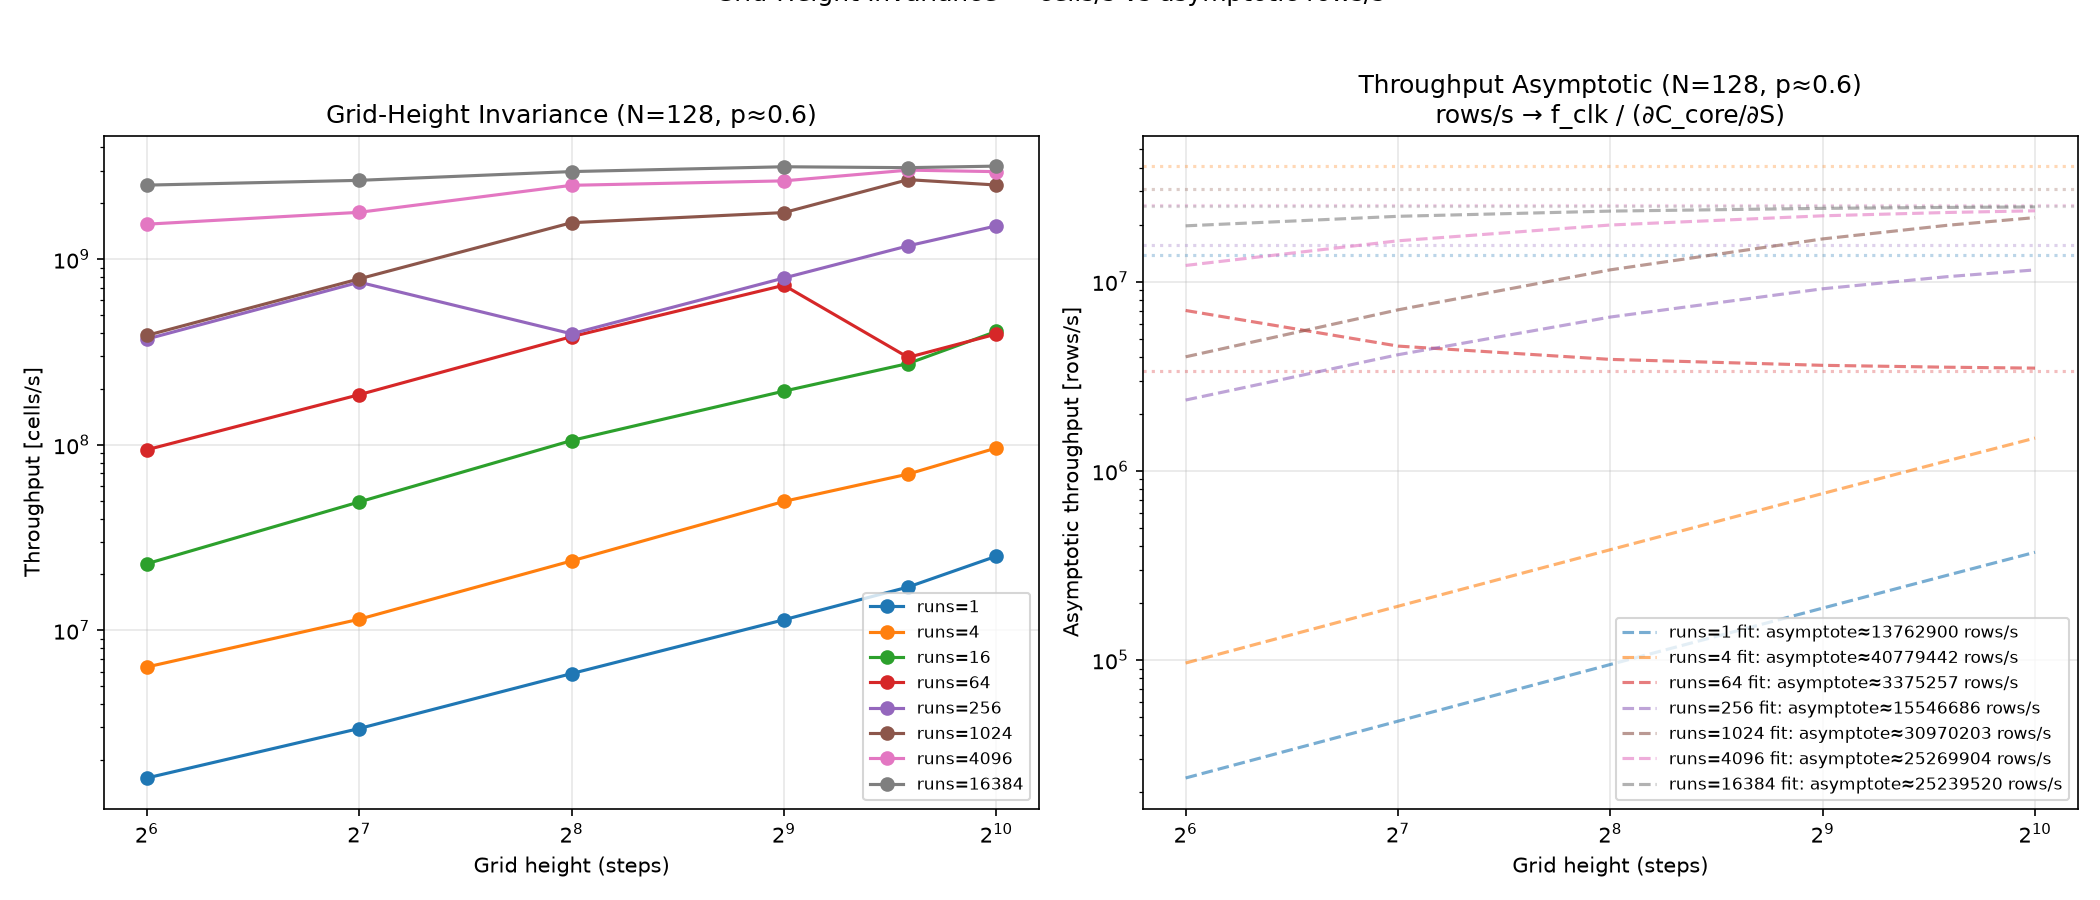

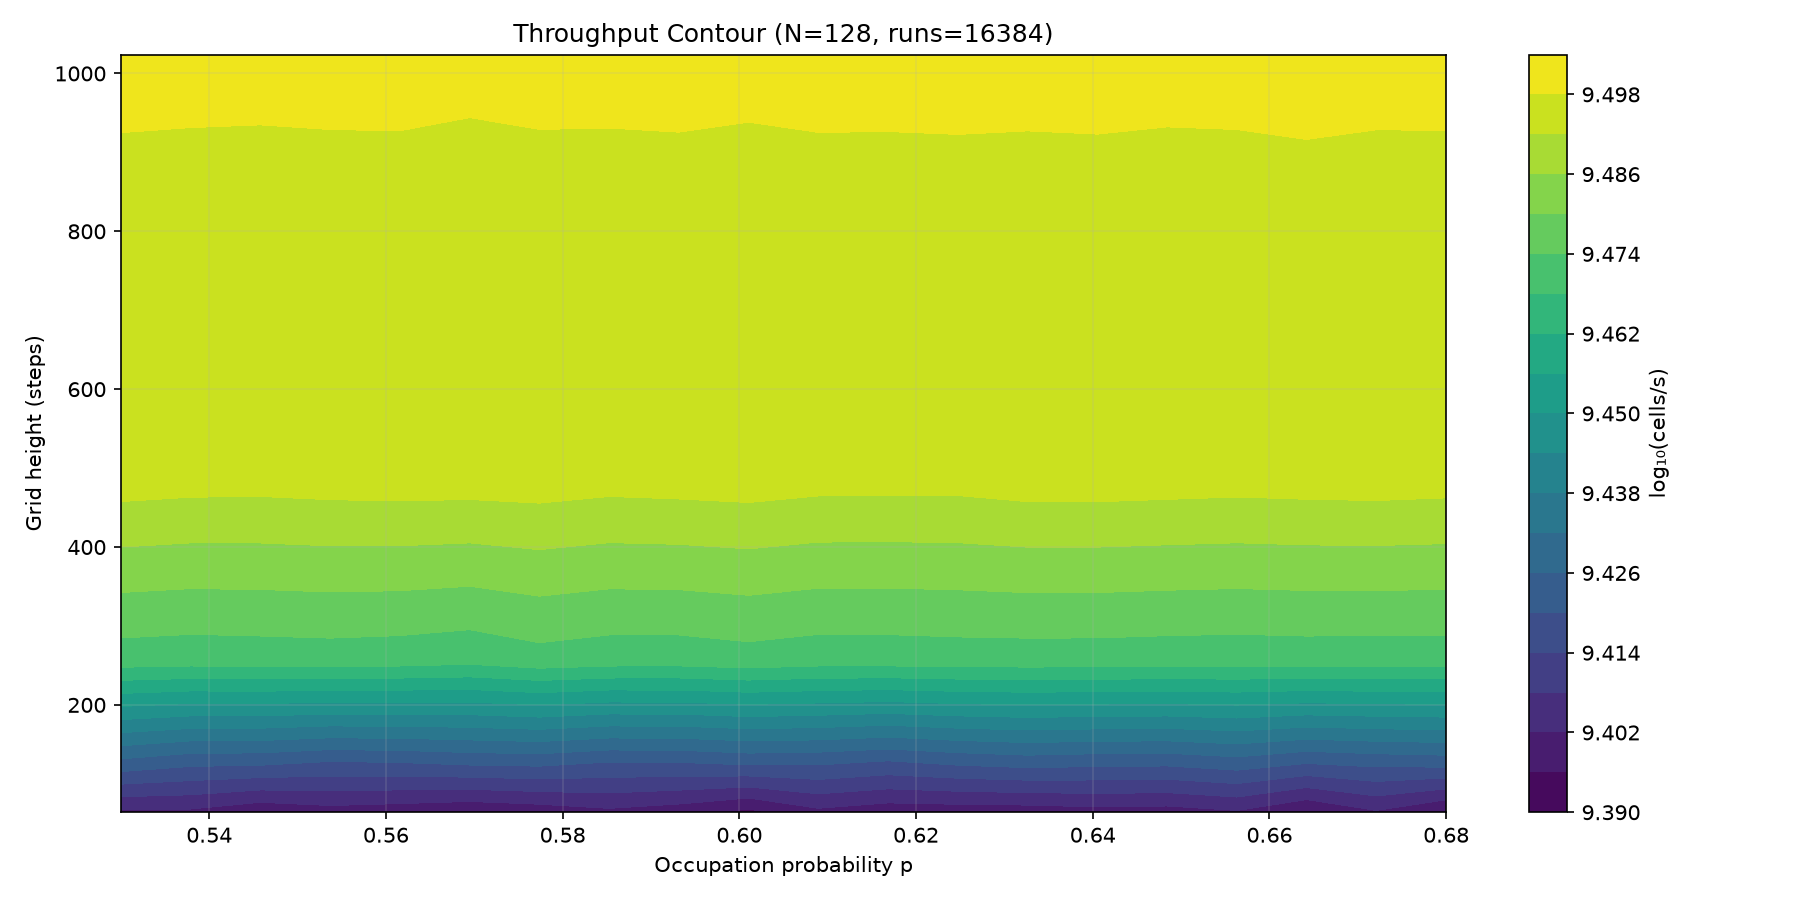


=== Determinism CV (N=128) ===
  steps=  64 runs=     1  CV=5.10%
  steps=  64 runs=     4  CV=5.80%
  steps=  64 runs=    16  CV=5.18%
  steps=  64 runs=    64  CV=6.52%
  steps=  64 runs=   256  CV=7.39%
  steps=  64 runs=  1024  CV=40.36%
  steps=  64 runs=  4096  CV=1.49%
  steps=  64 runs= 16384  CV=0.52%
  steps= 128 runs=     1  CV=7.03%
  steps= 128 runs=     4  CV=4.95%
  steps= 128 runs=    16  CV=6.40%
  steps= 128 runs=    64  CV=5.04%
  steps= 128 runs=   256  CV=6.54%
  steps= 128 runs=  1024  CV=1.29%
  steps= 128 runs=  4096  CV=0.80%
  steps= 128 runs= 16384  CV=0.29%
  steps= 256 runs=     1  CV=5.09%
  steps= 256 runs=     4  CV=6.39%
  steps= 256 runs=    16  CV=4.03%
  steps= 256 runs=    64  CV=5.19%
  steps= 256 runs=   256  CV=1.39%
  steps= 256 runs=  1024  CV=1.26%
  steps= 256 runs=  4096  CV=0.55%
  steps= 256 runs= 16384  CV=0.16%
  steps= 512 runs=     1  CV=3.54%
  steps= 512 runs=     4  CV=5.50%
  steps= 512 runs=    16  CV=4.55%
  steps= 512 runs=    

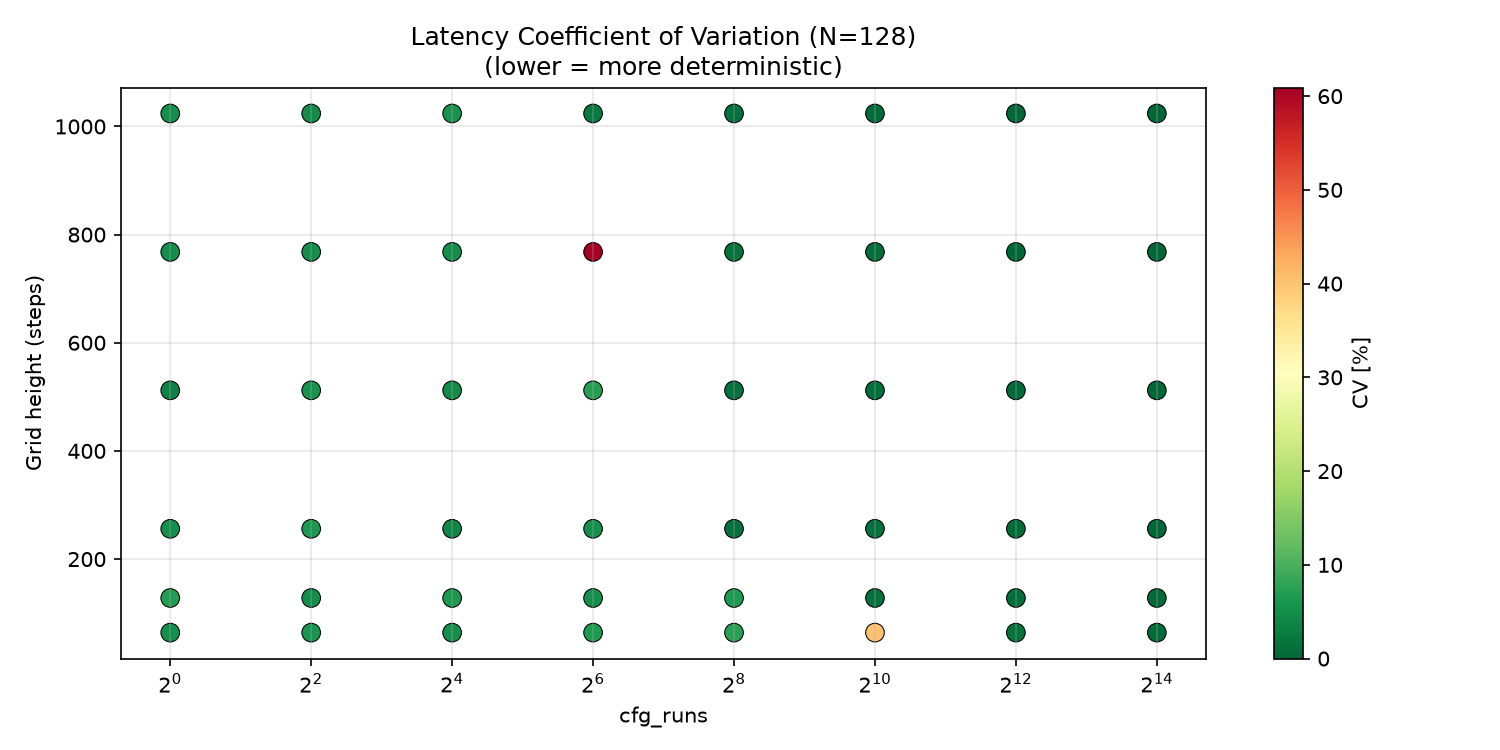

In [9]:
# Breakdown vs Throughput (side by side)
analysis.plot_breakdown_throughput(conn2, fpga_out / 'breakdown_throughput.png')
display(Image(filename=str(fpga_out / 'breakdown_throughput.png')))

# Asymptotic Breakdown
analysis.plot_breakdown_fit(conn2, fpga_out / 'breakdown_fit.png')
display(Image(filename=str(fpga_out / 'breakdown_fit.png')))

# Pipeline Efficiency
analysis.plot_pipeline_efficiency(conn2, fpga_out / 'pipeline_efficiency.png')
display(Image(filename=str(fpga_out / 'pipeline_efficiency.png')))

# Throughput Invariance
analysis.plot_throughput_invariance(conn2, fpga_out / 'throughput_invariance.png')
display(Image(filename=str(fpga_out / 'throughput_invariance.png')))

# Throughput Contour
analysis.plot_throughput_contour(conn2, fpga_out / 'throughput_contour.png')
display(Image(filename=str(fpga_out / 'throughput_contour.png')))

# Determinism CV (N=128)
analysis.plot_determinism_cv(conn2, fpga_out / 'determinism_cv.png', hw_width=128)
display(Image(filename=str(fpga_out / 'determinism_cv.png')))

conn2.close()

## Physics / DP Analysis

Three plots probing the directed percolation phase transition:

1. **Finite-Size Scaling**: Spanning probability curves for square grids
   N=64×64, 128×128, 180×180 with approximate data collapse
2. **Threshold Bootstrap**: Binomial logistic fit restricted to the transition
   region (0.001 < P_span < 0.999). Bootstrap via Binomial(n, p̂) resampling.
3. **Cluster Mass Curves**: Average reachable sites per spanning run vs p —
   a continuous order parameter that diverges near p_c.

All use `benchmark-2.sqlite3` (square-grid sessions only).


=== Finite-Size Scaling (square grids) ===
  N=64×64:  session=d1c5b94d  total_runs=327680
  N=128×128:  session=b76d637d  total_runs=327680
  N=180×180:  session=ba1fe7e8  total_runs=6553600
  p_c estimates: ['0.6038', '0.6098', '0.6124']
  Using p_c=0.6124 for collapse


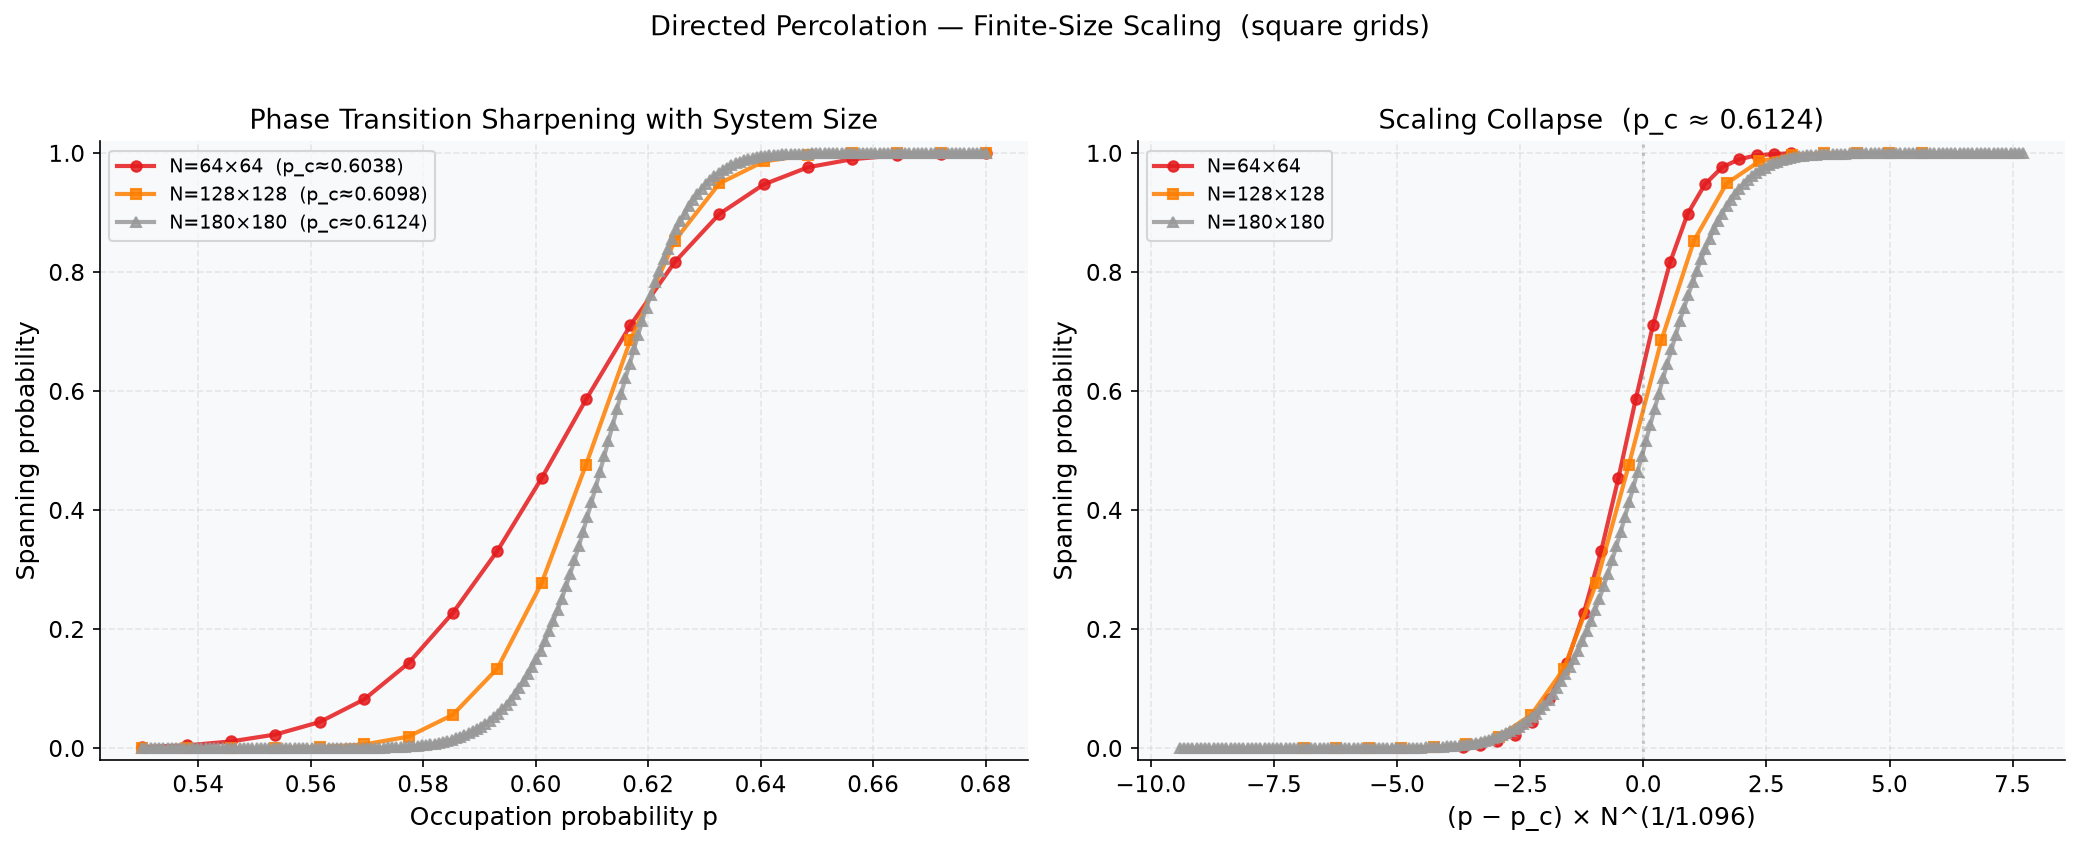

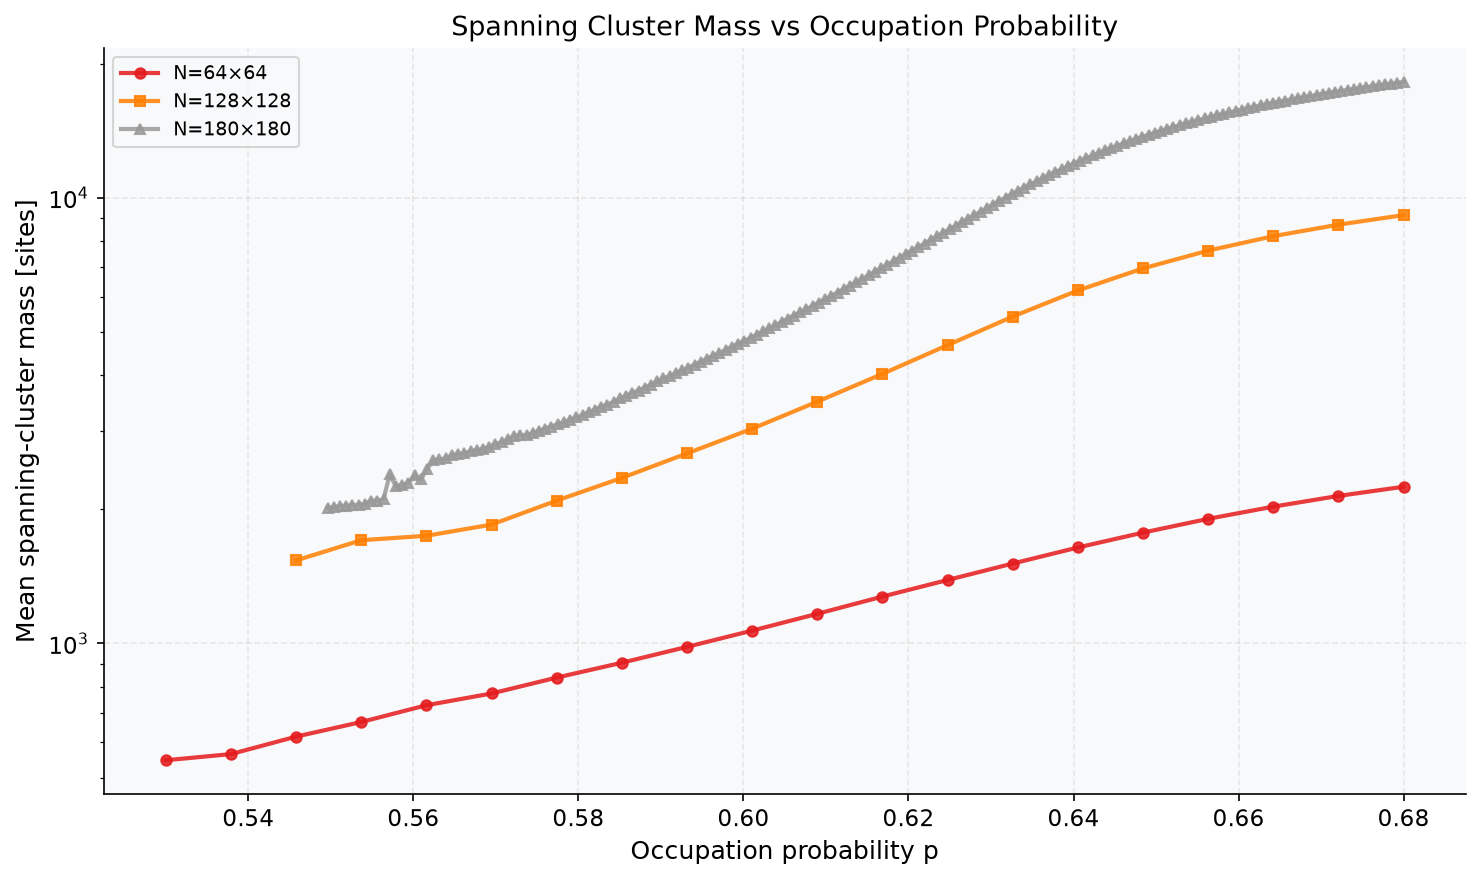

Physics plots generated.


In [10]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

db2_path = repo_root / 'python' / 'output' / 'benchmark.sqlite3'
conn2 = analysis._connect(db2_path)
physics_out = plot_dir / 'physics'
physics_out.mkdir(parents=True, exist_ok=True)

# 1. Finite-Size Scaling
analysis.plot_spanning_curves_multi_size(conn2, physics_out / 'finite_size_scaling.png')
display(Image(filename=str(physics_out / 'finite_size_scaling.png')))

# 3. Cluster Mass Curves (continuous observable, replaces Binder cumulant)
analysis.plot_cluster_mass_curves(conn2, physics_out / 'cluster_mass_curves.png')
display(Image(filename=str(physics_out / 'cluster_mass_curves.png')))

conn2.close()

print('Physics plots generated.')

In [11]:
conn = analysis._connect(db2_path)
try:
    for s in analysis.list_sessions(conn):
        payload = s.payload
        if payload.get("effective_hw_width") == 64 and payload.get("steps") == 64:
            print(s.session_id, s.created_at, payload.get("runs"), payload.get("repeats"))
finally:
    conn.close()

796846da-e44e-40a9-98b5-c3aca8c6d5fe 2026-05-28T14:57:40.653389+00:00 1 20
8151adc6-a529-47c2-be9b-26ba979f2b2e 2026-05-28T14:57:47.281643+00:00 4 20
10a6e3d9-a601-4460-a757-b31ff945d343 2026-05-28T14:57:53.906859+00:00 16 20
4f724a30-a26c-406b-9209-e71f371c4047 2026-05-28T14:58:00.520620+00:00 64 20
2a6eac46-f766-4bd6-802d-ad75b7be77a9 2026-05-28T14:58:07.138880+00:00 256 20
b3c94cb2-afdc-4809-b6cf-ca6f44130b0a 2026-05-28T14:58:16.680027+00:00 1024 20
da93d381-86ac-443f-a48c-b7f3fc1a9d2c 2026-05-28T14:58:29.745183+00:00 4096 20
d1c5b94d-ac4a-4c02-b21e-0decd5a7dc7c 2026-05-28T14:58:55.611804+00:00 16384 20


/home/alessio/Documenti/FPGA-project/python/percolation_uart/analysis/plots.py:1128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels([f"{x:.4f}" for x in ax2.get_xticks()], rotation=45)



=== Threshold Estimation (N=64, 2000 binomial bootstrap) ===
  Fit range: 0.5300 – 0.6721  (19 points)
  Logistic: a=75.0, b=-45.2
  p_c = −b/a = 0.603085
  Slope at p_c = a/4 = 18.7
  Bootstrap: median=0.601614, mean=0.602205
  95% CI: [0.601472, 0.603113]
  CI width: 0.001640


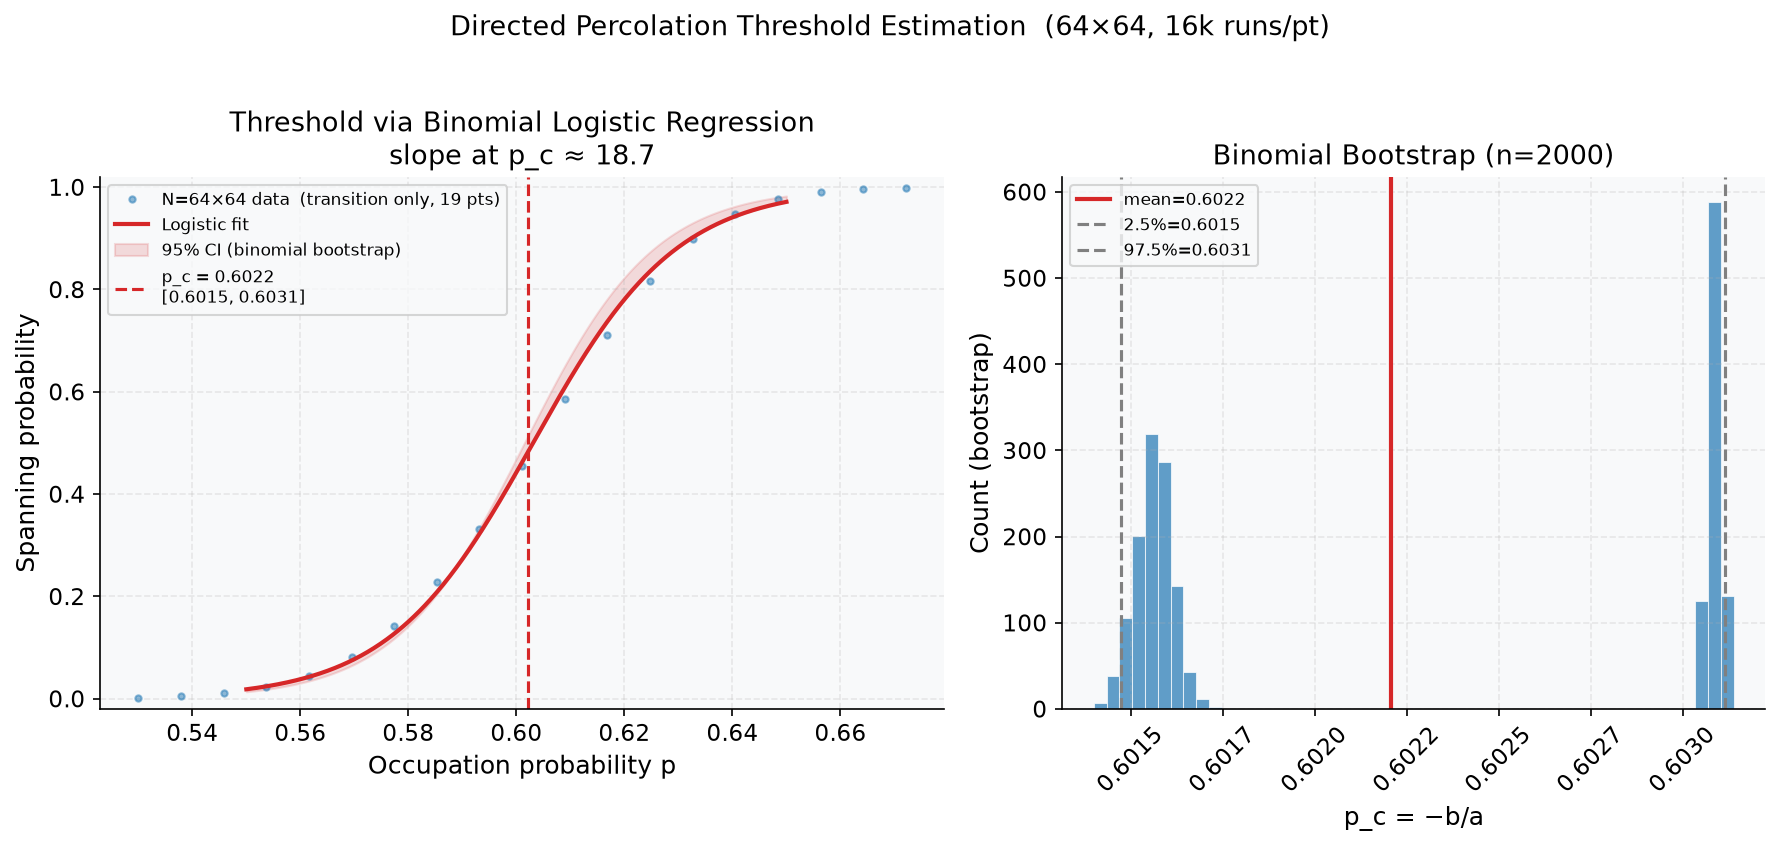

64x64 threshold plot generated.


In [12]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

db2_path = repo_root / 'python' / 'output' / 'benchmark.sqlite3'
conn2 = analysis._connect(db2_path)
physics_out = plot_dir / 'physics'
physics_out.mkdir(parents=True, exist_ok=True)

# sessione giusta per 64x64
session_64 = "d1c5b94d-ac4a-4c02-b21e-0decd5a7dc7c"

analysis.plot_threshold_bootstrap(
    conn2,
    physics_out / 'threshold_bootstrap_64.png',
    session_id=session_64,
)
display(Image(filename=str(physics_out / 'threshold_bootstrap_64.png')))

conn2.close()
print('64x64 threshold plot generated.')